## Meteorological computations

In this notebook you will see:
- how to compute the potential temperature from GRIB data
- how to compute the wind speed from GRIB data

### Components of earthkit

This tutorial uses the following earthkit components - click any logo to open the package documentation:

<div align="center">
  <br>
  <a href="https://earthkit-data.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-data-light.svg" alt="earthkit-data" width="200">
  </a>
  <a href="https://earthkit-meteo.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-meteo-light.svg" alt="earthkit-meteo" width="200">
  </a>
  <a href="https://earthkit-plots.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-plots-light.svg" alt="earthkit-plots" width="200">
  </a>
</div>

### 1. Getting the data

Get the input data containing temperature, specific humidity and wind analysis on pressure levels.

In [1]:
import earthkit.data as ekd

ds = ekd.from_source("sample", "tquv_pl_2x2.grib").to_fieldlist()
ds.head(6)

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
1,q,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
2,u,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
3,v,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
4,t,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll
5,q,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll


### 2. Computing potential temperature

This example shows how to compute the potential temperature with [earthkit.meteo.thermo.fieldlist.potential_temperature](https://earthkit-meteo.readthedocs.io/en/latest/autoapi/earthkit/meteo/thermo/fieldlist/potential_temperature.html#earthkit.meteo.thermo.fieldlist.potential_temperature).

In [2]:
from earthkit.meteo.thermo.fieldlist import potential_temperature

# select temperature fields
t = ds.sel({"parameter.variable": "t"})

ds_pt = potential_temperature(t)

Check the results.

In [3]:
ds_pt.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
1,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll
2,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,700,pressure,0,regular_ll
3,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,500,pressure,0,regular_ll
4,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,400,pressure,0,regular_ll
5,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,300,pressure,0,regular_ll


The resulting fieldlist was created in memory. You can save it into a file with `to_target()`.

In [4]:
ds_pt.to_target("file", "_pt_res.grib")

# read back saved data and check first 2 fields
ds_pt = ekd.from_source("file", "_pt_res.grib").to_fieldlist()
ds_pt.head(2)

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
1,pt,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll


The next cell plots the input temperature and the computed potential temperature fields on the same level.

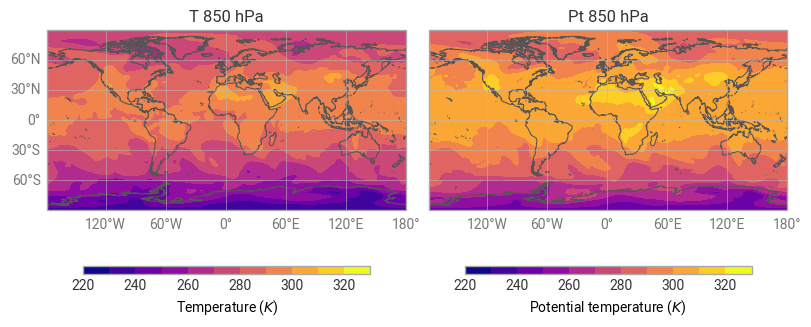

In [5]:
import earthkit.plots as ekp

figure = ekp.Figure(rows=1, columns=2)

level = 850
t_style = ekp.styles.Style(units="K", levels=list(range(220, 340, 10)))

subplot = figure.add_map(0, 0)
subplot.contourf(t.sel({"vertical.level": level}), style=t_style)
subplot.title("{shortName} {level} hPa")
subplot.legend()

subplot = figure.add_map(0, 1)
subplot.contourf(ds_pt.sel({"vertical.level": level}), style=t_style)
subplot.title("{shortName} {level} hPa")
subplot.legend()

figure.coastlines()
figure.gridlines()

figure.show()

### 3. Computing the wind speed

This example computes the wind speed with  [earthkit.meteo.wind.speed](https://earthkit-meteo.readthedocs.io/en/latest/autoapi/earthkit/meteo/wind/array/speed.html#earthkit.meteo.wind.array.speed).

In [6]:
ds = ekd.from_source("sample", "tquv_pl_2x2.grib").to_fieldlist()

In [7]:
from earthkit.meteo.wind.fieldlist import speed

# select the u and v fields. We assume here they
# are valid for the same set of levels
u = ds.sel({"parameter.variable": "u"})
v = ds.sel({"parameter.variable": "v"})

ds_ws = speed(u, v)

Check the results.

In [8]:
ds_ws.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
1,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll
2,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,700,pressure,0,regular_ll
3,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,500,pressure,0,regular_ll
4,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,400,pressure,0,regular_ll
5,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,300,pressure,0,regular_ll


Write out the results and read back in.

In [9]:
ds_ws.to_target("file", "_ws_res.grib")

# read back saved data and check first 2 fields
ds_ws = ekd.from_source("file", "_ws_res.grib").to_fieldlist()
ds_ws.head(2)

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
1,ws,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll


The next cell plots the wind arrows and the computed speed over a subarea for a given level.

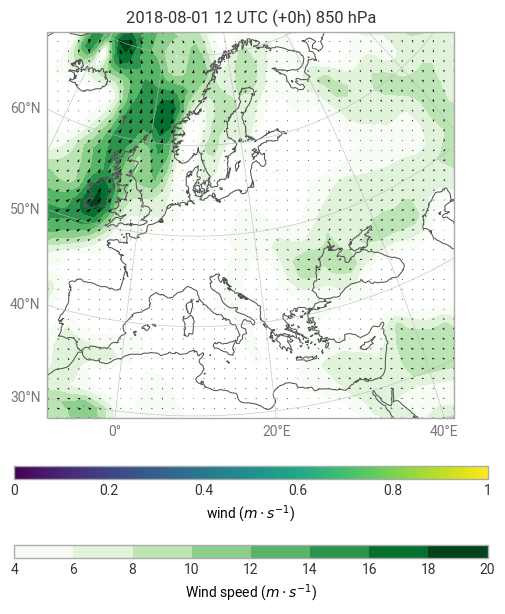

In [10]:
level = 850

chart = ekp.Map(domain="Europe", size=(6, 6))
chart.contourf(
    ds_ws.sel({"vertical.level": level}),
    units="m s-1",
    colors="Greens",
    levels=list(range(4, 22, 2)),
    alpha=1,
)
chart.quiver(u=u.sel({"vertical.level": level}), v=v.sel({"vertical.level": level}))
chart.coastlines()
chart.gridlines()
chart.legend()
chart.title(("{time:%Y-%m-%d %H} UTC (+{lead_time}h) {level} hPa"))

chart.show()